In [ ]:
# 既にインストールされていれば不要
!pip install stim

In [2]:
import stim
import numpy as np
import matplotlib.pyplot as plt

# グラフのスタイル設定
plt.rcParams['font.size'] = 12

# スティーン符号のパリティ検査行列 H (ハミング符号のH行列と同じ)
# 各列が 1 から 7 の二進数表現に対応するように配置
H_MATRIX = np.array([
[0, 0, 0, 1, 1, 1, 1], # leads to IIIZZZZ, IIIXXXX
[0, 1, 1, 0, 0, 1, 1], # leads to IZZIIZZ, IXXIIXX
[1, 0, 1, 0, 1, 0, 1] # leads to ZIZIZIZ, XIXIXIX
])

def decode_steane(measurement_result):
    """
    7ビットの測定結果からシンドロームを計算し，エラー訂正後の論理値を返す．
    """
    # 1. シンドローム計算 s = H * v
    syndrome = (H_MATRIX @ measurement_result) % 2 # 長さ3のシンドロームベクトル

    # 2. シンドロームを整数値に変換(ハミング符号の性質を利用したエラー位置特定)
    # X, Zエラーの発生箇所のindex + 1
    error_idx_plus_1 = syndrome[0]*4 + syndrome[1]*2 + syndrome[2]

    # 3. エラー訂正
    corrected_result = measurement_result.copy()
    if error_idx_plus_1 > 0:
        error_idx = int(error_idx_plus_1 - 1)
        # エラーのあったビットを反転
        corrected_result[error_idx] = (corrected_result[error_idx] + 1) % 2

    # 4. 論理値の判定(スティーン符号の論理Z演算子ZZZZZZZ, XXXXXXXを計算)
    logical_corrected = np.sum(corrected_result) % 2
    return logical_corrected

In [3]:
def check_steane_x_error(p, shots=50000):
    circuit = stim.Circuit()
    q = list(range(7))

    # 1. エンコード: 論理|0_L> の生成(|0>をエンコーディング回路に入力)
    circuit.append("R", q)
    circuit.append("H", [1, 2, 3])
    circuit.append("CX", [0, 5, 0, 6, 1, 0, 3, 4, 2, 6, 1, 5, 2, 4, 3, 6, 1, 4, 2, 0, 3, 5])

    # 2. ノイズ印加: Xエラー
    circuit.append("X_ERROR", q, p)

    # 3. 測定: Z基底
    circuit.append("M", q)

    results = circuit.compile_sampler().sample(shots)

    # 4. 復号とエラーカウント
    errors = 0
    for res in results:
        if decode_steane(res) == 1: # 初期状態|0_L> から反転し， Z_L の測定値が-1になったらエラー
            errors += 1
    return errors / shots

In [4]:
def check_steane_z_error(p, shots=50000):
    circuit = stim.Circuit()
    q = list(range(7))

    # 1. エンコード: 論理|+_L> の生成
    circuit.append("R", q)
    circuit.append("H", [0]) # 物理|+>をエンコーディング回路に入力
    circuit.append("H", [1, 2, 3])
    circuit.append("CX", [0, 5, 0, 6, 1, 0, 3, 4, 2, 6, 1, 5, 2, 4, 3, 6, 1, 4, 2, 0, 3, 5])

    # 2. Zエラー印加
    circuit.append("Z_ERROR", q, p)

    # 3. 測定: X基底(HをかけてからM)
    circuit.append("H", q)
    circuit.append("M", q)

    results = circuit.compile_sampler().sample(shots)

    errors = 0
    for res in results:
        if decode_steane(res) == 1: # 初期状態|+_L> (X基底でパリティ0) から反転したらエラー
            errors += 1
    return errors / shots

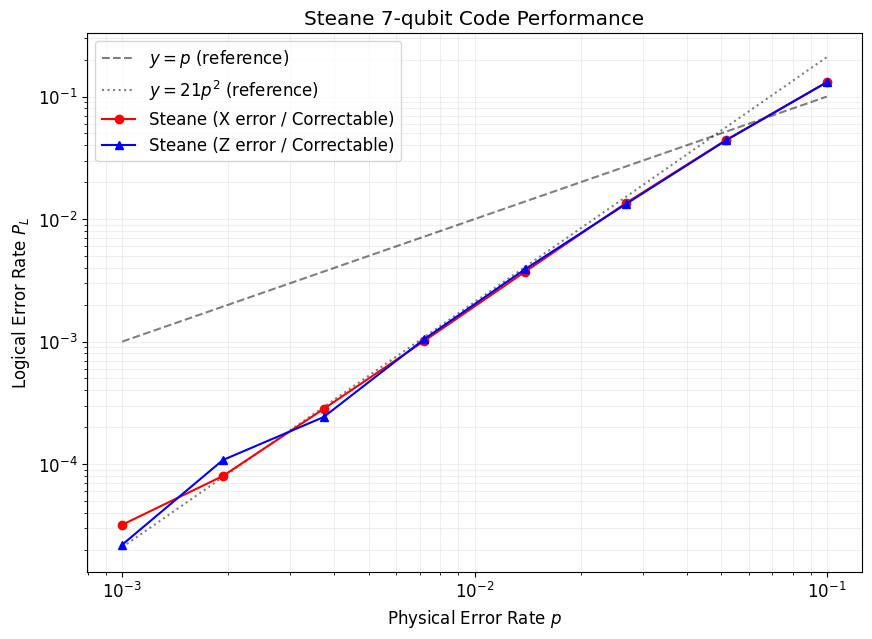

In [5]:
# パラメータ設定
probs = np.logspace(-3, -1, 8)
shots = 500_000

# データ収集
y_steane_x = [check_steane_x_error(p, shots) for p in probs]
y_steane_z = [check_steane_z_error(p, shots) for p in probs]

# プロット
plt.figure(figsize=(10, 7))
plt.loglog(probs, probs, 'k--', alpha=0.5, label="$y=p$ (reference)")
plt.loglog(probs, 21 * probs**2, 'k:', alpha=0.5, label="$y=21p^2$ (reference)")
plt.loglog(probs, y_steane_x, 'o-', c="r", label="Steane (X error / Correctable)")
plt.loglog(probs, y_steane_z, '^-', c="b", label="Steane (Z error / Correctable)")

plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("Steane 7-qubit Code Performance")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()